# `run_simulation` API Examples

This notebook demonstrates the high-level `run_simulation` API introduced in `nbody_streams` v1.4+.

It covers:
1. The `Species` dataclass and its convenience constructors
2. **Single-species** run — a Globular Cluster
3. **Multi-species** run — a Dwarf Galaxy (dark matter + stars + gas tracers)
4. Reading snapshots back with `ParticleReader`

All examples use `architecture='cpu'` so they run without a GPU.  
Switch to `architecture='gpu'` to use CUDA acceleration.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import nbody_streams as nb
from nbody_streams import (
    run_simulation,
    Species,
    PerformanceWarning,
    ParticleReader,
    make_plummer_sphere,
    G_DEFAULT,
)

print(f"nbody_streams version : {nb.__version__}")
print(f"G_DEFAULT             : {G_DEFAULT:.3e}  (kpc (km/s)^2 Msun^-1)")

nbody_streams version : 1.0.0
G_DEFAULT             : 4.301e-06  (kpc (km/s)^2 Msun^-1)


---
## 1. The `Species` dataclass

Every particle population is described by a `Species` object.

| Field | Description |
|---|---|
| `name` | Unique string identifier (`'dark'`, `'star'`, `'gas'`, `'bh'`, …) |
| `N` | Number of particles |
| `mass` | Scalar (all particles equal-mass) or per-particle array of shape `(N,)` |
| `softening` | Gravitational softening length — scalar or per-particle array |

Two convenience constructors are available for the most common types:

In [2]:
# Convenience constructors
dm    = Species.dark(N=5_000, mass=2e5, softening=0.1)
stars = Species.star(N=1_000, mass=5e4, softening=0.03)

# Arbitrary name — e.g. a central black hole
bh = Species(name='bh', N=1, mass=1e8, softening=0.001)

# Per-particle mass example
m_arr = np.linspace(1e4, 3e4, 500)   # lighter -> heavier across the array
gas   = Species(name='gas', N=500, mass=m_arr, softening=0.05)

for s in [dm, stars, bh, gas]:
    m_info = f"{np.mean(s.mass):.2e}" if not np.isscalar(s.mass) else f"{s.mass:.2e}"
    print(f"  {s.name:<6}  N={s.N:>5}   mass={m_info}   softening={np.mean(s.softening):.4f}")

  dark    N= 5000   mass=2.00e+05   softening=0.1000
  star    N= 1000   mass=5.00e+04   softening=0.0300
  bh      N=    1   mass=1.00e+08   softening=0.0010
  gas     N=  500   mass=2.00e+04   softening=0.0500


---
## 2. Single-species run — Globular Cluster

A Globular Cluster can be modelled as a self-gravitating system of equal-mass stars.  
Here we use a Plummer sphere as initial conditions.

**Physical setup:**
- $N = 5_000$ stars (small for a quick demo)
- Total mass $M = 1 \times 10^4\,M_\odot$
- Scale radius $a = 5\,\text{pc} = 0.005\,\text{kpc}$
- Softening $\epsilon = 0.5\,\text{pc} = 0.0005\,\text{kpc}$
- Integration time: $T = 0.01\,\text{kpc/(km/s)} \approx 10\,\text{Myr}$

In [3]:
# --- Initial conditions ---
N_gc    = 5_000
M_gc    = 1e4          # Msun
a_gc    = 0.005        # kpc  (5 pc)
eps_gc  = 0.0005       # kpc  (1 pc)

xv_gc, _ = make_plummer_sphere(N_gc, M_total=M_gc, a=a_gc)

# --- Species definition ---
gc_species = Species.star(N=N_gc, mass=M_gc / N_gc, softening=eps_gc)
print(f"Species: {gc_species}")

# --- Run simulation ---
out_gc = Path('./output/gc')
result_gc = run_simulation(
    xv_gc, [gc_species],
    time_start=0.0,
    time_end=0.05,
    dt=2e-5,
    architecture='gpu',
    method='direct',
    kernel='dehnen_k1',
    output_dir=str(out_gc),
    save_snapshots=True,
    snapshots=10,
    verbose=True,
)

print(f"\nFinal phase-space shape: {result_gc['star'].shape}")

Species: Species(name='star', N=5000, mass=2.0, softening=0.0005)
GPU N-body Integration
Particles: 5,000
  [star] N=5,000
Time: 0.000e+00 -> 5.000e-02 (dt=2.000e-05)
Steps: 2,500 (2,500 remaining)
Kernel: dehnen_k1, Softening: variable
External potential: No
Snapshots: 10 (every ~250 steps)
Restart files: every 1000 steps

Transferring data to GPU...
Computing initial forces (compiling CUDA kernel)...

Starting integration...
Saved snapshot snap: 000 at step 0, time 0.000000e+00...
  Step    125/2500 | t=2.5000e-03 | Snapshots: 1/10 | 1763.3 steps/s | avg 0.6ms/step | ETA 1s
  Step    250/2500 | t=5.0000e-03 | Snapshots: 1/10 | 1336.3 steps/s | avg 0.7ms/step | ETA 2s
Saved snapshot id=001 at step 278, time 5.560000e-03...
  Step    375/2500 | t=7.5000e-03 | Snapshots: 2/10 | 1207.6 steps/s | avg 0.8ms/step | ETA 2s
  Step    500/2500 | t=1.0000e-02 | Snapshots: 2/10 | 1195.6 steps/s | avg 0.8ms/step | ETA 2s
Saved snapshot id=002 at step 556, time 1.112000e-02...
  Step    625/2500 |

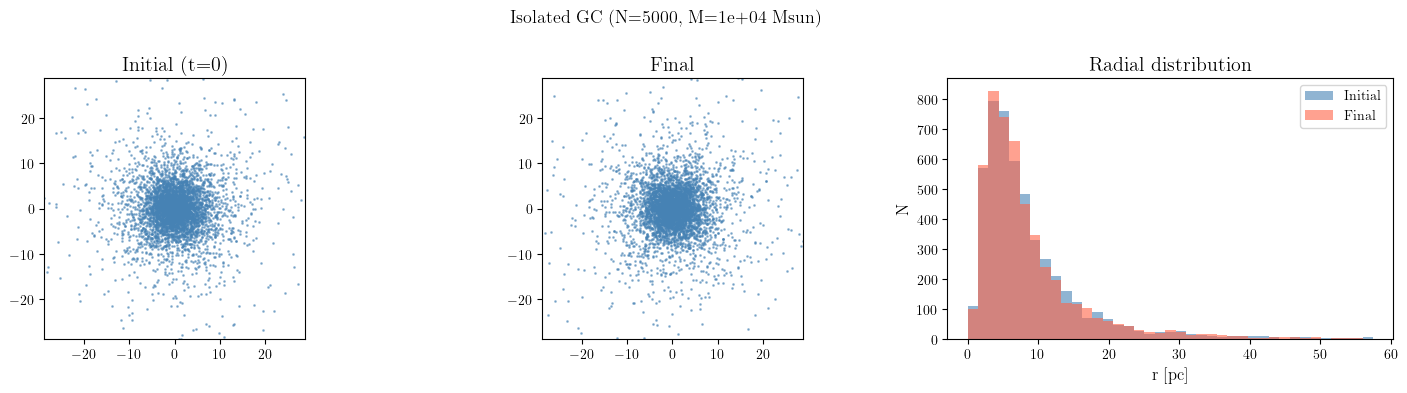

CoM drift:        0.000 pc
Half-mass radius initial: 6.49 pc
Half-mass radius final:   6.42 pc


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

centre_i = xv_gc[:, :3].mean(axis=0)
centre_f = result_gc['star'][:, :3].mean(axis=0)

pos_i_rel = (xv_gc[:, :3]             - centre_i) * 1e3
pos_f_rel = (result_gc['star'][:, :3] - centre_f) * 1e3

# Use same limits on both panels so comparison is honest
lim = np.percentile(np.abs(pos_i_rel), 98) * 1.2

for ax, pos, title in zip(axes[:2], [pos_i_rel, pos_f_rel],
                                     ['Initial (t=0)', 'Final']):
    ax.scatter(pos[:, 0], pos[:, 1], s=1, alpha=0.5, c='steelblue')
    ax.set_xlim(-lim, lim);  ax.set_ylim(-lim, lim)
    # ax.set_xlabel('Δx  [pc]');  ax.set_ylabel('Δy  [pc]')
    ax.set_title(title);  ax.set_aspect('equal')

# Radial distribution — most informative for isolated relaxation
r_i = np.linalg.norm(pos_i_rel, axis=1)
r_f = np.linalg.norm(pos_f_rel, axis=1)
bins = np.linspace(0, np.percentile(r_i, 99), 40)
axes[2].hist(r_i, bins=bins, alpha=0.6, label='Initial', color='steelblue')
axes[2].hist(r_f, bins=bins, alpha=0.6, label='Final',   color='tomato')
axes[2].set_xlabel('r  [pc]');  axes[2].set_ylabel('N')
axes[2].set_title('Radial distribution')
axes[2].legend()

fig.suptitle(f'Isolated GC  (N={N_gc}, M={M_gc:.0e} Msun)', fontsize=13)
plt.tight_layout()
plt.show()

# Sanity checks
print(f"CoM drift:        {np.linalg.norm(centre_f - centre_i)*1e3:.3f} pc")
print(f"Half-mass radius initial: {np.median(r_i):.2f} pc")
print(f"Half-mass radius final:   {np.median(r_f):.2f} pc")

---
## 3. Multi-species run — Dwarf Galaxy

A dwarf galaxy can be approximated as three collisionless components:

| Component | Particles | Total mass | Scale radius | Notes |
|---|---|---|---|---|
| **Dark matter** | 10_000 | $10^9\,M_\odot$ | 1 kpc | dominant halo |
| **Stars** | 400 | $4 \times 10^7\,M_\odot$ | 0.3 kpc | embedded stellar body |
| **Gas tracers** | 200 | $2 \times 10^7\,M_\odot$ | 0.5 kpc | collisionless gas proxy |

All components are initialised as Plummer spheres and evolve under their
mutual gravity. 

Please note, the system is not in equilibirum at the initial time.

In [5]:
# -------------------------------------------------------
# Initial conditions: one Plummer sphere per component
# -------------------------------------------------------
N_dm, M_dm, a_dm    = 10_000, 1e9,  1.0    # dark matter halo
N_st, M_st, a_st    =   400, 4e7,  0.3    # stellar body
N_gas, M_gas, a_gas =   200, 2e7,  0.5    # gas tracers

# please note this is a horrible example, ran for simplicity with direct GPU. 
xv_dm,  _ = make_plummer_sphere(N_dm,  M_total=M_dm,  a=a_dm)
xv_st,  _ = make_plummer_sphere(N_st,  M_total=M_st,  a=a_st)
xv_gas, _ = make_plummer_sphere(N_gas, M_total=M_gas, a=a_gas)

# Stack: dark matter first, then stars, then gas
xv_all = np.vstack([xv_dm, xv_st, xv_gas])
print(f"Combined phase-space shape: {xv_all.shape}")

# -------------------------------------------------------
# Species definitions  (same order as the stacked array)
# -------------------------------------------------------
sp_dm  = Species.dark(N=N_dm,  mass=M_dm  / N_dm,  softening=0.1 )
sp_st  = Species.star(N=N_st,  mass=M_st  / N_st,  softening=0.03)
sp_gas = Species(name='gas',   N=N_gas, mass=M_gas / N_gas, softening=0.05)

species_list = [sp_dm, sp_st, sp_gas]
for s in species_list:
    print(f"  {s.name:<6}  N={s.N:<5}  m_particle={s.mass:.2e} Msun  eps={s.softening} kpc")

Combined phase-space shape: (10600, 6)
  dark    N=10000  m_particle=1.00e+05 Msun  eps=0.1 kpc
  star    N=400    m_particle=1.00e+05 Msun  eps=0.03 kpc
  gas     N=200    m_particle=1.00e+05 Msun  eps=0.05 kpc


In [6]:
# -------------------------------------------------------
# Run the simulation
# -------------------------------------------------------
import warnings

out_dwarf = Path('./output/dwarf')

with warnings.catch_warnings():
    warnings.simplefilter('ignore', PerformanceWarning)   # small N, we know
    result_dwarf = run_simulation(
        xv_all,
        species_list,
        time_start=0.0,
        time_end=0.2,           # ~200 Myr
        dt=1e-5,
        architecture='gpu',
        method='direct',
        kernel='spline',
        output_dir=str(out_dwarf),
        save_snapshots=True,
        snapshots=10,
        verbose=True,
    )

# result is a dict[str, ndarray]
for name, arr in result_dwarf.items():
    print(f"  result['{name}'].shape = {arr.shape}")

GPU N-body Integration
Particles: 10,600
  [dark] N=10,000
  [star] N=400
  [gas] N=200
Time: 0.000e+00 -> 2.000e-01 (dt=1.000e-05)
Steps: 20,000 (20,000 remaining)
Kernel: spline, Softening: variable
External potential: No
Snapshots: 10 (every ~2,000 steps)
Restart files: every 1000 steps

Transferring data to GPU...
Computing initial forces (compiling CUDA kernel)...

Starting integration...
Saved snapshot snap: 000 at step 0, time 0.000000e+00...
  Step   1000/20000 | t=1.0000e-02 | Snapshots: 1/10 | 664.9 steps/s | avg 1.5ms/step | ETA 29s
  Step   2000/20000 | t=2.0000e-02 | Snapshots: 1/10 | 659.2 steps/s | avg 1.5ms/step | ETA 27s
Saved snapshot id=001 at step 2222, time 2.222000e-02...
  Step   3000/20000 | t=3.0000e-02 | Snapshots: 2/10 | 649.5 steps/s | avg 1.5ms/step | ETA 26s
  Step   4000/20000 | t=4.0000e-02 | Snapshots: 2/10 | 646.6 steps/s | avg 1.5ms/step | ETA 25s
Saved snapshot id=002 at step 4444, time 4.444000e-02...
  Step   5000/20000 | t=5.0000e-02 | Snapshots: 

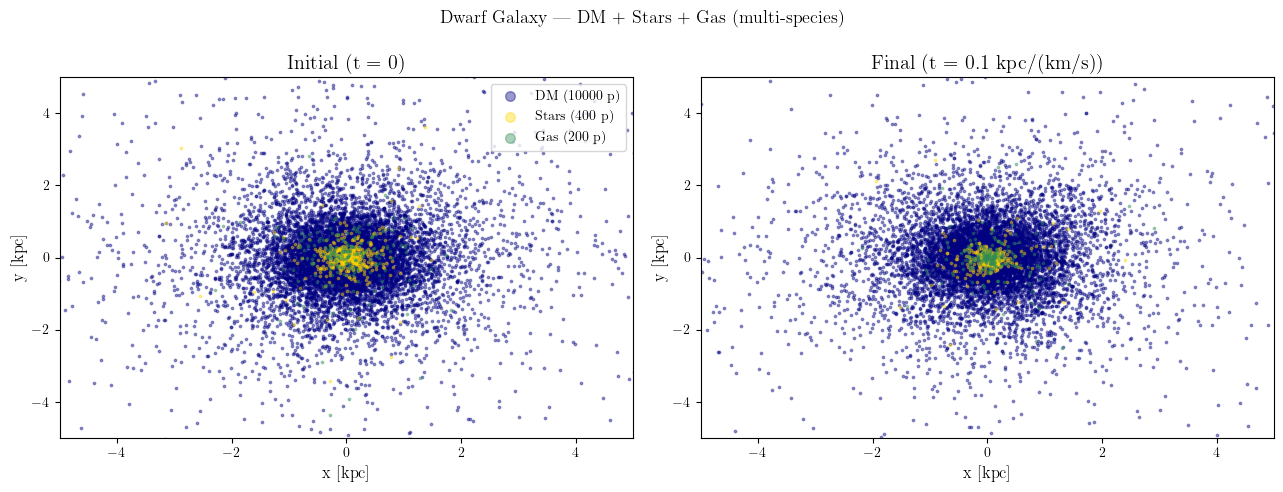

In [7]:
# -------------------------------------------------------
# Visualise the three components
# -------------------------------------------------------
colors = {'dark': 'navy', 'star': 'gold', 'gas': 'seagreen'}
labels = {'dark': f'DM ({N_dm} p)', 'star': f'Stars ({N_st} p)', 'gas': f'Gas ({N_gas} p)'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, xv_init in [('dark', xv_dm), ('star', xv_st), ('gas', xv_gas)]:
    for ax, pos, ls in zip(axes, [xv_init[:, :3], result_dwarf[name][:, :3]],
                            ['-', '--']):
        ax.scatter(pos[:, 0], pos[:, 1],
                   s=3, alpha=0.4, c=colors[name], label=labels[name] if ls == '-' else None)

for ax, title in zip(axes, ['Initial (t = 0)', 'Final (t = 0.1 kpc/(km/s))']):
    ax.set_xlabel('x  [kpc]')
    ax.set_ylabel('y  [kpc]')
    ax.set_title(title)
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)

axes[0].legend(markerscale=4, loc='upper right')
fig.suptitle('Dwarf Galaxy — DM + Stars + Gas (multi-species)', fontsize=13)
plt.tight_layout()
plt.show()

---
## 4. Reading snapshots with `ParticleReader`

The HDF5 snapshots written by `run_simulation` store each species in its own
group.  `ParticleReader` exposes them through a `snap.species` dictionary.
The legacy `snap.dark` / `snap.star` aliases still work for backward compat.

In [8]:
# Find snapshot files written by the dwarf galaxy run
h5_files = sorted(out_dwarf.glob('*.h5'))
print(f"Found {len(h5_files)} snapshot file(s)")

if h5_files:
    reader = ParticleReader(str(h5_files[0]))
    print(f"\nReader metadata:")
    print(f"  num_snapshots : {len(reader.Snapshots)}")
    print(f"  species_list  : {[s.name for s in reader.species_list]}")
    print(f"  num_dark      : {reader.num_dark}")
    print(f"  num_star      : {reader.num_star}")

    # Read first and last snapshots
    snap0 = reader.read_snapshot(int(reader.Snapshots[0]))
    snapN = reader.read_snapshot(int(reader.Snapshots[-1]))

    print(f"\nSnap 0:")
    for name, data in snap0.species.items():
        print(f"  [{name}]  posvel shape: {data['posvel'].shape}  time: {snap0.time:.4f}")

    print(f"\nSnap N:")
    for name, data in snapN.species.items():
        print(f"  [{name}]  posvel shape: {data['posvel'].shape}  time: {snapN.time:.4f}")

    # Backward-compat aliases
    print(f"\nBackward-compat  snap0.dark['posvel'].shape  = {snap0.dark['posvel'].shape}")
    print(f"Backward-compat  snap0.star['posvel'].shape  = {snap0.star['posvel'].shape}")

Found 1 snapshot file(s)

Reader metadata:
  num_snapshots : 10
  species_list  : ['dark', 'star', 'gas']
  num_dark      : 10000
  num_star      : 400

Snap 0:
  [dark]  posvel shape: (10000, 6)  time: 0.0000
  [star]  posvel shape: (400, 6)  time: 0.0000
  [gas]  posvel shape: (200, 6)  time: 0.0000

Snap N:
  [dark]  posvel shape: (10000, 6)  time: 0.2000
  [star]  posvel shape: (400, 6)  time: 0.2000
  [gas]  posvel shape: (200, 6)  time: 0.2000

Backward-compat  snap0.dark['posvel'].shape  = (10000, 6)
Backward-compat  snap0.star['posvel'].shape  = (400, 6)


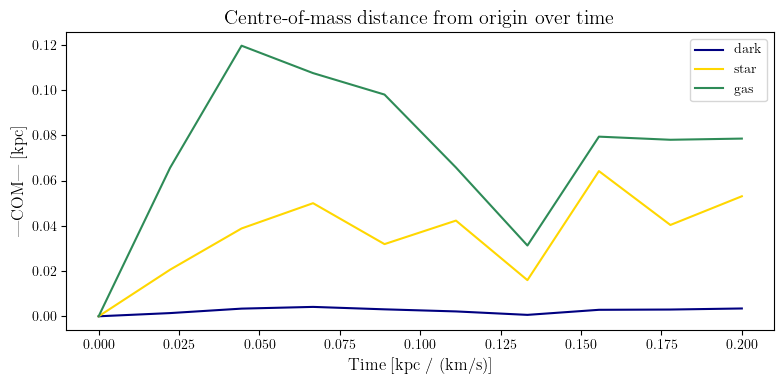

In [9]:
# -------------------------------------------------------
# Time evolution: track the centre-of-mass of each species
# -------------------------------------------------------
if h5_files:
    times   = []
    com_dm  = []
    com_st  = []
    com_gas = []

    for snap_idx in reader.Snapshots:
        snap = reader.read_snapshot(int(snap_idx))
        t    = snap.time
        times.append(t)

        for name, com_list in [('dark', com_dm), ('star', com_st), ('gas', com_gas)]:
            if name in snap.species:
                pos = snap.species[name]['posvel'][:, :3]
                com_list.append(np.mean(pos, axis=0))

    times   = np.array(times)
    com_dm  = np.array(com_dm)
    com_st  = np.array(com_st)
    com_gas = np.array(com_gas)

    fig, ax = plt.subplots(figsize=(8, 4))
    for com, name, c in [(com_dm, 'dark',  'navy'),
                          (com_st, 'star',  'gold'),
                          (com_gas,'gas',   'seagreen')]:
        if len(com):
            ax.plot(times, np.linalg.norm(com, axis=1), label=name, color=c)

    ax.set_xlabel('Time  [kpc / (km/s)]')
    ax.set_ylabel('|COM|  [kpc]')
    ax.set_title('Centre-of-mass distance from origin over time')
    ax.legend()
    plt.tight_layout()
    plt.show()

---
## 5. Performance hints

`run_simulation` emits `PerformanceWarning` automatically when thresholds are exceeded:

| Configuration | Threshold | Recommendation |
|---|---|---|
| CPU direct | N > 20 000 | Switch to `method='tree'` or `architecture='gpu'` |
| GPU direct | N > 500 000 | GPU+Tree (coming soon) |
| Any | N > 2 000 000 | GPU+Tree required |

See the [README](../README.md) for detailed solver benchmarks.

In [10]:
import warnings
from nbody_streams import PerformanceWarning
from nbody_streams.species import _emit_performance_warnings

# Demonstrate the warning system
with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter('always')
    _emit_performance_warnings(25_000, 'cpu', 'direct')
    if w:
        print(f"Warning type  : {w[0].category.__name__}")
        print(f"Warning message: {str(w[0].message)}")

Warning type  : PerformanceWarning
Warning message: 25,000 particles with CPU direct summation is O(N^2) and will be very slow. Consider architecture='cpu' + method='tree', or architecture='gpu'.
